<a href="https://colab.research.google.com/github/chinadaily1111/GitStudy/blob/master/menuetest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /drive

上传菜品图片：


Saving d4223fff90202405678f35ef15fe94ad.jpg to d4223fff90202405678f35ef15fe94ad.jpg


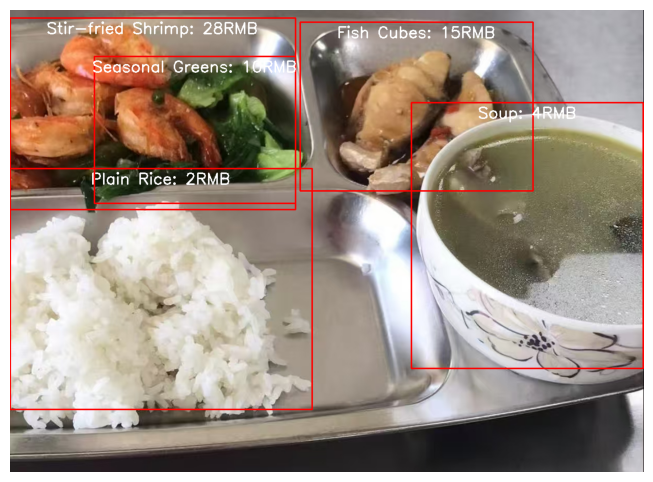


===== 🍽️ 菜品结算清单 =====
• 白米饭：¥2
• 油爆虾：¥28
• 清炒时蔬：¥10
• 鱼块：¥15
• 汤：¥4

💰 合计总价：¥59


In [ ]:
!pip install --upgrade "volcengine-python-sdk[ark]"
# ================= 配置 =================
API_KEY = "ark-a3c103ed-4b9e-488a-aa8d-2347e3ed2431-bcdc6"
MODEL_ID = "doubao-1-5-vision-pro-32k-250115"
# ========================================

import base64
import requests
import json
import os
import cv2
import re
from google.colab import drive, files
import matplotlib.pyplot as plt

drive.mount('/drive', force_remount=True)
requests.packages.urllib3.disable_warnings()

MENU_PATH = "/drive/MyDrive/menutest/menu.json"
PIC_DIR = "/drive/MyDrive/menutest/pic"
os.makedirs(PIC_DIR, exist_ok=True)

# 👇 你的固定菜单
menu_data = [
    {"chinese": "蛋炒饭", "english": "Egg Fried Rice", "price": 12},
    {"chinese": "番茄炒蛋", "english": "Tomato Scrambled Eggs", "price": 15},
    {"chinese": "油爆虾", "english": "Stir-fried Shrimp", "price": 28},
    {"chinese": "清炒时蔬", "english": "Seasonal Greens", "price": 10},
    {"chinese": "鱼块", "english": "Fish Cubes", "price": 15},
    {"chinese": "白米饭", "english": "Plain Rice", "price": 2},
    {"chinese": "汤", "english": "Soup", "price": 4}
]

with open(MENU_PATH, "w", encoding="utf-8") as f:
    json.dump(menu_data, f, ensure_ascii=False, indent=2)

with open(MENU_PATH, "r", encoding="utf-8") as f:
    menu = json.load(f)

en2cn = {item["english"].lower(): item["chinese"] for item in menu}
en2price = {item["english"].lower(): item["price"] for item in menu}
allowed_names = [item["english"] for item in menu]

# 上传图片
print("\n上传菜品图片：")
uploaded = files.upload()
img_name = next(iter(uploaded))
save_path = os.path.join(PIC_DIR, img_name)
with open(save_path, "wb") as wf:
    wf.write(uploaded[img_name])

def to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()
img_b64 = to_b64(save_path)

img = cv2.imread(save_path)
H, W = img.shape[:2]

# ===================== 强约束提示词 =====================
prompt = f"""
You can only recognize dishes in this list: {allowed_names}
Output ONLY JSON, no extra words.
Format:
{{"items": [{{"name":"EnglishName","box":[x1,y1,x2,y2]}}]}}
box values MUST be 0~1000
"""

headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json"
}
data = {
    "model": MODEL_ID,
    "messages": [
        {"role":"user","content":[
            {"type":"image_url","image_url":{"url":f"data:image/jpeg;base64,{img_b64}"}},
            {"type":"text","text":prompt}
        ]}
    ]
}

try:
    res = requests.post(
        "https://ark.cn-beijing.volces.com/api/v3/chat/completions",
        headers=headers, json=data, verify=False, timeout=30
    )
    result_text = res.json()["choices"][0]["message"]["content"]
    json_raw = re.search(r"\{[\s\S]*\}", result_text, re.DOTALL).group()
    result = json.loads(json_raw)

    img = cv2.imread(save_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    total_price = 0

    for item in result["items"]:
        x1k = int(item["box"][0])
        y1k = int(item["box"][1])
        x2k = int(item["box"][2])
        y2k = int(item["box"][3])

        # 👇 核心：0~1000 转真实像素
        x1 = int((x1k / 1000.0) * W)
        y1 = int((y1k / 1000.0) * H)
        x2 = int((x2k / 1000.0) * W)
        y2 = int((y2k / 1000.0) * H)

        en_name = item["name"].strip().lower()
        cn_name = en2cn.get(en_name, "未知菜品")
        price = en2price.get(en_name, 0)
        total_price += price

        # 画红框
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # 英文显示在框内居中偏上
        text = item["name"]+": "+str(price)+"RMB"
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 1
        thick = 2
        (tw, th), _ = cv2.getTextSize(text, font, scale, thick)
        cx = (x1 + x2) // 2 - tw // 2
        cy = y1 + 30
        cv2.putText(img, text, (cx, cy), font, scale, (255, 255, 255), thick)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # ===================== 中文结算 =====================
    print("\n===== 🍽️ 菜品结算清单 =====")
    for item in result["items"]:
        en = item["name"].strip().lower()
        cn = en2cn.get(en, "未知菜品")
        p = en2price.get(en, 0)
        print(f"• {cn}：¥{p}")
    print(f"\n💰 合计总价：¥{total_price}")

except Exception as e:
    print("错误：", str(e))